# Interest Rate Model: Nelson-Siegel DNS with VAR & XGBoost Forecasting

## Project Overview
This notebook models the **US Treasury Yield Curve** using the **Dynamic Nelson-Siegel (DNS)** framework.

### Pipeline Summary
```
Raw CSV Data
    → Phase 1: Data Cleaning  (parse dates, sort, interpolate, trim)
    → Phase 2: EDA            (yield history, spread, correlation, PCA)
    → Phase 3: NS Fitting     (fit β₀, β₁, β₂ per date; free & fixed λ)
    → Phase 4: λ Optimization (grid search over lambda)
    → Phase 5: Kalman Filter  (DNS — state-space estimation of betas)
    → Phase 6: VAR Forecast   (rolling 1-step beta forecasting)
    → Phase 7: XGBoost        (lag-feature ML forecast of betas)
    → Phase 8: Yield Curve    (reconstruct & evaluate full yield curve)
```

### Dataset
- **Source**: US Treasury Par Yield Curve Rates (1990–2026)
- **Maturities**: 1mo, 3mo, 6mo, 1yr, 2yr, 3yr, 5yr, 7yr, 10yr, 20yr, 30yr

---
## Phase 1: Imports & Configuration

In [30]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import subprocess, sys
for pkg in ['seaborn', 'statsmodels', 'xgboost']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import seaborn as sns
from statsmodels.tsa.api import VAR
from xgboost import XGBRegressor
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore", category=ValueWarning)


plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True

print('All imports successful.')

All imports successful.


---
## Phase 2: Data Loading & Cleaning

### Steps
1. Load raw CSV
2. Parse `Date` column into proper `datetime` format
3. Sort chronologically and set as index
4. Inspect & handle missing values
5. Trim to a date range where all maturities (including 30yr) are available

In [31]:
# ── 2.1  Load raw data ────────────────────────────────────────────────────────
df = pd.read_csv('US-par-yield-curve-rates-2006-2026.csv')
print('Raw shape:', df.shape)
df.head()

Raw shape: (5094, 12)


,Date,1 mo,3 mo,6 mo,1 yr,2 yr,3 yr,5 yr,7 yr,10 yr,20 yr,30 yr
0,02-09-2006,4.32,4.52,4.67,4.66,4.66,4.62,4.55,4.55,4.54,4.72,4.51
1,02-10-2006,4.36,4.53,4.70,4.70,4.69,4.67,4.59,4.59,4.59,4.76,4.55
2,02/13/2006,4.38,4.55,4.71,4.70,4.68,4.66,4.58,4.58,4.58,4.76,4.56
3,02/14/2006,4.42,4.55,4.72,4.71,4.69,4.68,4.61,4.61,4.62,4.80,4.60
4,02/15/2006,4.39,4.55,4.70,4.70,4.71,4.68,4.60,4.60,4.61,4.78,4.58


In [32]:
# ── 2.2  Inspect dtypes before parsing ───────────────────────────────────────
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5094 entries, 0 to 5093
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5094 non-null   str    
 1   1 mo    5094 non-null   float64
 2   3 mo    5091 non-null   float64
 3   6 mo    5094 non-null   float64
 4   1 yr    5094 non-null   float64
 5   2 yr    5094 non-null   float64
 6   3 yr    5094 non-null   float64
 7   5 yr    5094 non-null   float64
 8   7 yr    5094 non-null   float64
 9   10 yr   5094 non-null   float64
 10  20 yr   5094 non-null   float64
 11  30 yr   5094 non-null   float64
dtypes: float64(11), str(1)
memory usage: 527.4 KB


In [33]:
# ── 2.3  Parse Date column ────────────────────────────────────────────────────
# Raw dates may use '-' as separator (e.g. '01-31-2000'); normalise to '/'
# then parse with explicit format to avoid ambiguity.
df['Date'] = df['Date'].str.replace('-', '/', regex=False)
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Sort chronologically and set as the DataFrame index
df = df.sort_values('Date').set_index('Date')

print('Date range after parsing:', df.index.min(), '→', df.index.max())
df.head()

Date range after parsing: 2006-02-09 00:00:00 → 2026-06-18 00:00:00


,1 mo,3 mo,6 mo,1 yr,2 yr,3 yr,5 yr,7 yr,10 yr,20 yr,30 yr
Date,,,,,,,,,,,
2006-02-09,4.32,4.52,4.67,4.66,4.66,4.62,4.55,4.55,4.54,4.72,4.51
2006-02-10,4.36,4.53,4.70,4.70,4.69,4.67,4.59,4.59,4.59,4.76,4.55
2006-02-13,4.38,4.55,4.71,4.70,4.68,4.66,4.58,4.58,4.58,4.76,4.56
2006-02-14,4.42,4.55,4.72,4.71,4.69,4.68,4.61,4.61,4.62,4.80,4.60
2006-02-15,4.39,4.55,4.70,4.70,4.71,4.68,4.60,4.60,4.61,4.78,4.58


In [34]:
# ── 2.4  Missing value audit ─────────────────────────────────────────────────
print('Null counts per column:')
print(df.isnull().sum())

Null counts per column:
1 mo     0
3 mo     3
6 mo     0
1 yr     0
2 yr     0
3 yr     0
5 yr     0
7 yr     0
10 yr    0
20 yr    0
30 yr    0
dtype: int64


In [35]:
# ── 2.5  Handle missing values ────────────────────────────────────────────────

# '3 mo': only a small number of gaps → linear interpolation is safe.
df['3 mo'] = df['3 mo'].interpolate()

# '30 yr': was not published between 2002-02 and 2006-02.
# Rather than imputing a long gap, we trim the dataset to start
# when the 30yr series resumes so ALL maturities are available.
print('Rows where 30yr is null:', df['30 yr'].isnull().sum())
print('Example null 30yr dates (first 5):')
print(df[df['30 yr'].isnull()].index[:5])

Rows where 30yr is null: 0
Example null 30yr dates (first 5):
DatetimeIndex([], dtype='datetime64[us]', name='Date', freq=None)


In [36]:
# ── 2.6  Trim to complete data range ─────────────────────────────────────────
# Keep only rows from 2006-02-09 onwards (when 30yr was reinstated).
df = df[df.index >= '2006-02-09']

print('Cleaned shape:', df.shape)
print('Nulls remaining:')
print(df.isnull().sum())

Cleaned shape: (5094, 11)
Nulls remaining:
1 mo     0
3 mo     0
6 mo     0
1 yr     0
2 yr     0
3 yr     0
5 yr     0
7 yr     0
10 yr    0
20 yr    0
30 yr    0
dtype: int64


---
## Phase 3: Exploratory Data Analysis (EDA)

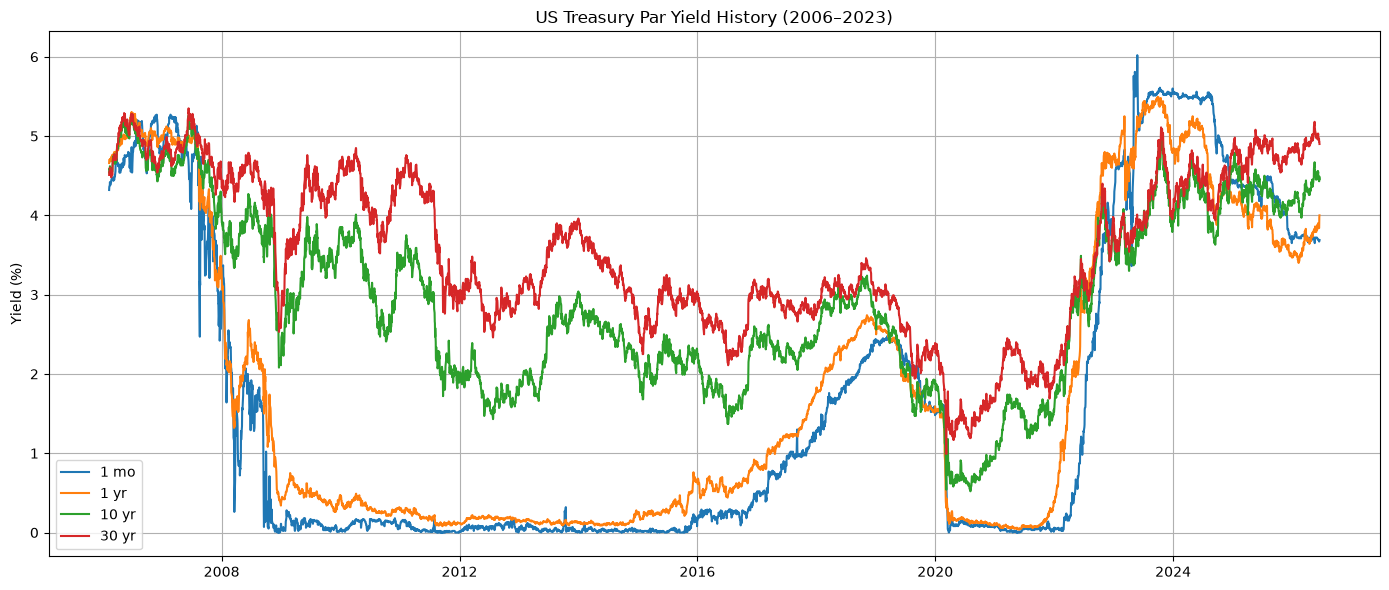

In [37]:
# ── 3.1  Yield history for key maturities ────────────────────────────────────
# Plot a representative subset of maturities to see the overall shape of
# interest rate history: falling rates post-2000 GFC, zero-bound era,
# and the sharp rise in 2022-23.
key_cols = ['1 mo', '1 yr', '10 yr', '30 yr']

for c in key_cols:
    plt.plot(df.index, df[c], label=c)

plt.legend()
plt.title('US Treasury Par Yield History (2006–2023)')
plt.ylabel('Yield (%)')
plt.tight_layout()
plt.show()

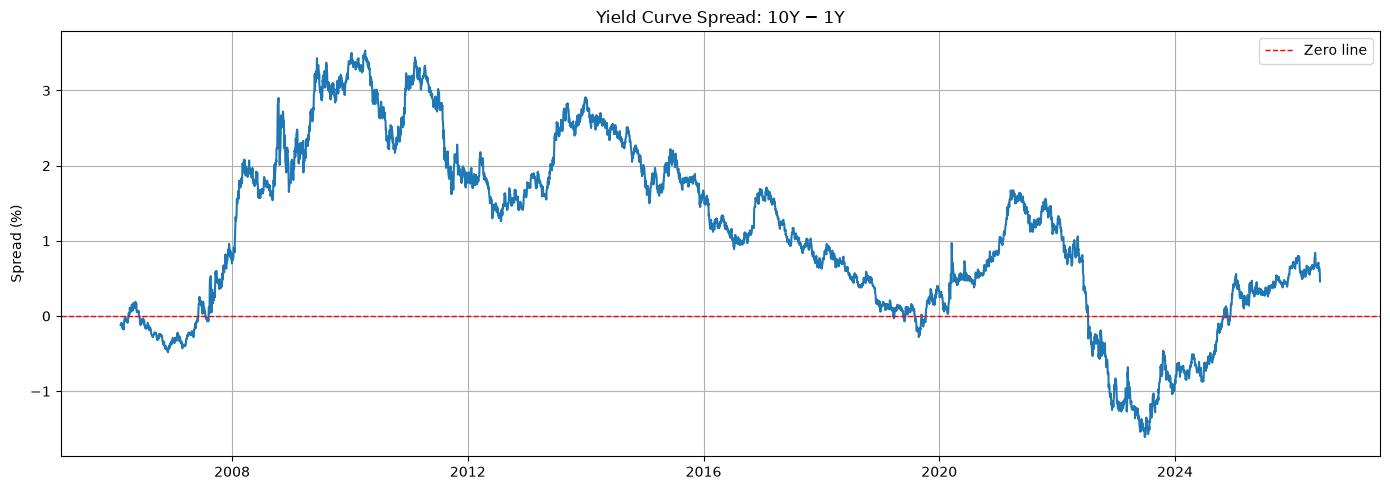

In [38]:
# ── 3.2  Yield-curve spread  (10yr − 1yr) ────────────────────────────────────
# The spread between long- and short-term rates is a classic recession signal:
# a negative spread (inversion) has historically preceded recessions.
# Formula: Spread_t = r(10yr)_t − r(1yr)_t

df['Spread'] = df['10 yr'] - df['1 yr']

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Spread'])
plt.axhline(0, linestyle='--', color='red', linewidth=1, label='Zero line')
plt.title('Yield Curve Spread: 10Y − 1Y')
plt.ylabel('Spread (%)')
plt.legend()
plt.tight_layout()
plt.show()

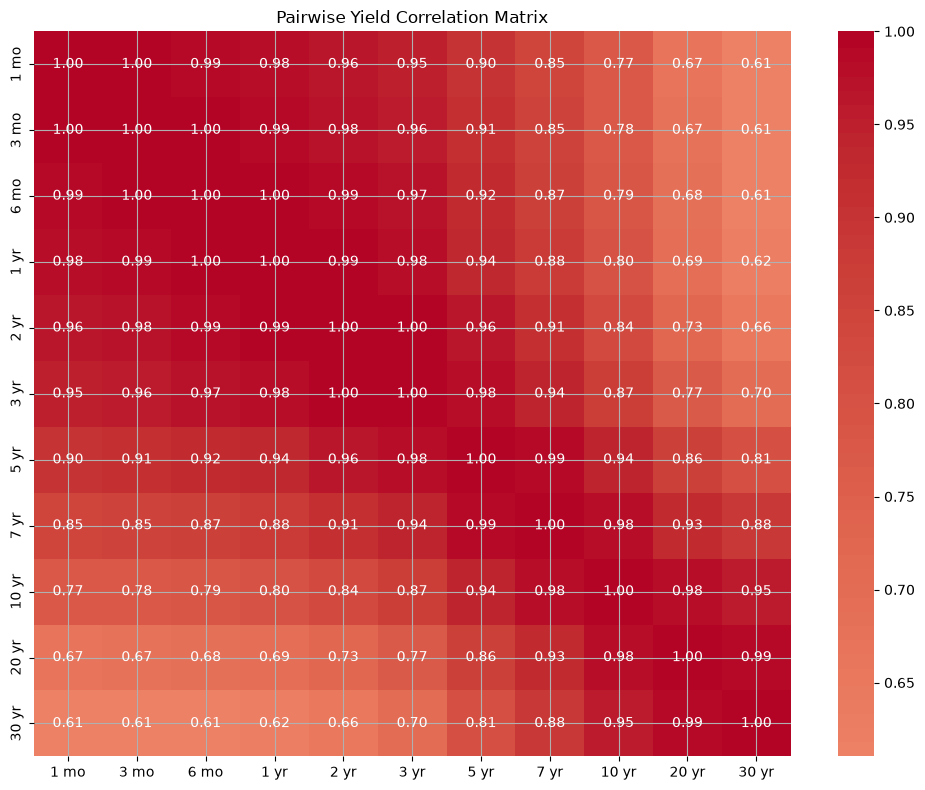

In [39]:
# ── 3.3  Correlation matrix ───────────────────────────────────────────────────
# All maturity yields tend to be highly correlated (driven by the same macro
# environment), but the short vs. long end can diverge during policy cycles.
corr = df.drop(columns='Spread').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Pairwise Yield Correlation Matrix')
plt.tight_layout()
plt.show()

In [40]:
# ── 3.4  Principal Component Analysis (PCA) ───────────────────────────────────
# PCA on yield curves is well-established: typically ~3 components explain
# >99% of variance, interpreted as:
#   PC1 → Level   (parallel shift of the curve)
#   PC2 → Slope   (steepening / flattening)
#   PC3 → Curvature (hump / butterfly)
# This motivates the 3-factor Nelson-Siegel model below.

yield_cols = ['1 mo','3 mo','6 mo','1 yr','2 yr','3 yr','5 yr','7 yr','10 yr','20 yr','30 yr']
pca = PCA()
pca.fit(df[yield_cols])

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print('Explained variance by component:')
for i, (ev, cv) in enumerate(zip(explained, cumulative)):
    print(f'  PC{i+1}: {ev:.4f}  (cumulative: {cv:.4f})')
    if cv > 0.999:
        break

Explained variance by component:
  PC1: 0.9208  (cumulative: 0.9208)
  PC2: 0.0675  (cumulative: 0.9884)
  PC3: 0.0096  (cumulative: 0.9979)
  PC4: 0.0013  (cumulative: 0.9992)


---
## Phase 4: Nelson-Siegel Model

### The Formula

The **Nelson-Siegel (NS)** model fits a smooth yield curve using three factors:

$$
y(\tau) = \beta_0 + \beta_1 \cdot L_1(\tau, \lambda) + \beta_2 \cdot L_2(\tau, \lambda)
$$

where the **factor loadings** are:

$$
L_1(\tau, \lambda) = \frac{1 - e^{-\tau/\lambda}}{\tau/\lambda}
\qquad \text{(Slope loading — starts at 1, decays to 0)}
$$

$$
L_2(\tau, \lambda) = \frac{1 - e^{-\tau/\lambda}}{\tau/\lambda} - e^{-\tau/\lambda}
\qquad \text{(Curvature loading — hump shape)}
$$

| Parameter | Interpretation |
|-----------|----------------|
| $\beta_0$ | **Level** — long-run yield (where the curve ends up) |
| $\beta_1$ | **Slope** — short-end adjustment (negative → normal upward curve) |
| $\beta_2$ | **Curvature** — hump / butterfly in the middle of the curve |
| $\lambda$ | **Decay parameter** — controls where the hump peaks |

Fitting is done by **minimising the sum of squared errors** between model and observed yields.

In [41]:
# ── 4.1  Maturity grid (in years) ────────────────────────────────────────────
# Each value corresponds to one yield column in the dataset.
tau = np.array([
    1/12,   # 1 month
    3/12,   # 3 months
    6/12,   # 6 months
    1,      # 1 year
    2,      # 2 years
    3,
    5,
    7,
    10,
    20,
    30
])

yield_cols = ['1 mo','3 mo','6 mo','1 yr','2 yr','3 yr','5 yr','7 yr','10 yr','20 yr','30 yr']

In [42]:
# ── 4.2  Nelson-Siegel factor loadings & model ────────────────────────────────

def L1(tau, lam):
    """Slope loading: (1 - exp(-τ/λ)) / (τ/λ)"""
    return (1 - np.exp(-tau / lam)) / (tau / lam)


def L2(tau, lam):
    """Curvature loading: L1(τ,λ) - exp(-τ/λ)"""
    return (1 - np.exp(-tau / lam)) / (tau / lam) - np.exp(-tau / lam)


def nelson_siegel(tau, beta0, beta1, beta2, lam):
    """
    Nelson-Siegel yield curve model.

    y(τ) = β₀ + β₁·L₁(τ,λ) + β₂·L₂(τ,λ)

    Parameters
    ----------
    tau   : array of maturities (years)
    beta0 : level factor
    beta1 : slope factor
    beta2 : curvature factor
    lam   : decay/shape parameter
    """
    return beta0 + beta1 * L1(tau, lam) + beta2 * L2(tau, lam)

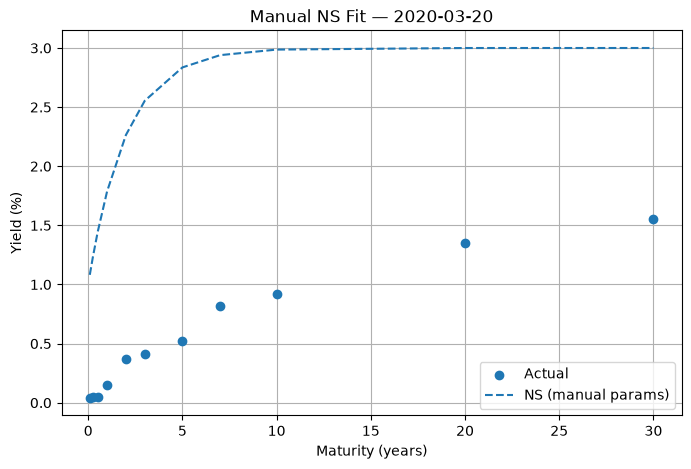

In [43]:
# ── 4.3  Manual parameter inspection on a single date ─────────────────────────
# Before optimising, visually inspect what the model looks like with
# manually chosen parameters. Useful for sanity-checking the model shape.

date = '2020-03-20'   # COVID market stress date
y_actual = df.loc[date, yield_cols].values

# Manual guess at parameters
beta0, beta1, beta2, lam = 3.0, -2.0, 2.0, 2.0

y_manual = nelson_siegel(tau, beta0, beta1, beta2, lam)

plt.figure(figsize=(8, 5))
plt.scatter(tau, y_actual, label='Actual', zorder=5)
plt.plot(tau, y_manual, label='NS (manual params)', linestyle='--')
plt.xlabel('Maturity (years)')
plt.ylabel('Yield (%)')
plt.title(f'Manual NS Fit — {date}')
plt.legend()
plt.show()

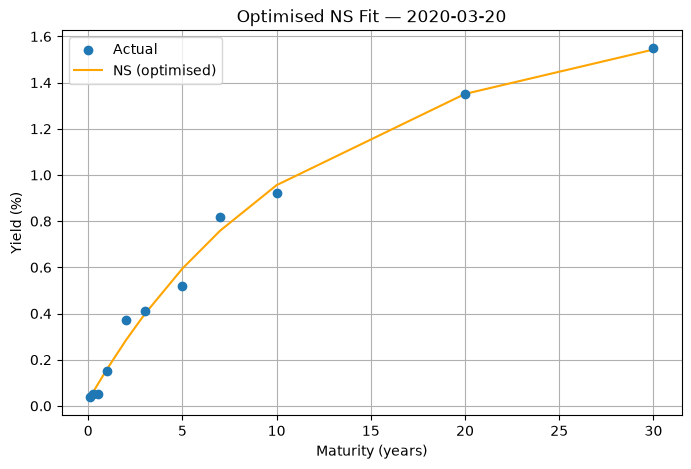

Level  β₀ = 1.9814
Slope  β₁ = -1.9593
Curve  β₂ = -0.0000
Lambda λ  = 6.7913


In [44]:
# ── 4.4  Optimised NS fit for one date ───────────────────────────────────────
# Minimise SSE = Σ (y_observed - y_NS)² over (β₀, β₁, β₂, λ)
# using the L-BFGS-B algorithm which supports box constraints.

def objective_free(params):
    """SSE objective: free lambda."""
    b0, b1, b2, lam = params
    y_hat = nelson_siegel(tau, b0, b1, b2, lam)
    return np.sum((y_actual - y_hat) ** 2)


x0 = [1.0, -1.0, 1.0, 2.0]   # initial guess

res = minimize(
    objective_free, x0,
    method='L-BFGS-B',
    bounds=[(0, 10), (-10, 10), (-10, 10), (0.01, 10)]
)

b0_opt, b1_opt, b2_opt, lam_opt = res.x
y_fit = nelson_siegel(tau, b0_opt, b1_opt, b2_opt, lam_opt)

plt.figure(figsize=(8, 5))
plt.scatter(tau, y_actual, label='Actual', zorder=5)
plt.plot(tau, y_fit, label='NS (optimised)', color='orange')
plt.xlabel('Maturity (years)')
plt.ylabel('Yield (%)')
plt.title(f'Optimised NS Fit — {date}')
plt.legend()
plt.show()

print(f'Level  β₀ = {b0_opt:.4f}')
print(f'Slope  β₁ = {b1_opt:.4f}')
print(f'Curve  β₂ = {b2_opt:.4f}')
print(f'Lambda λ  = {lam_opt:.4f}')

---
## Phase 5: Rolling NS Fitting — Free λ vs Fixed λ

We fit the NS model to **every date** in the dataset and compare two strategies:

| Strategy | λ | Pros | Cons |
|----------|---|------|------|
| **Free λ** | Optimised per date | Maximum flexibility | Can be unstable; non-linear 4D optimisation |
| **Fixed λ** | Constant (e.g. 2.0) | Linear 3-factor problem; stable; easy to use in Kalman filter | Less flexible per date |

In [45]:
# ── 5.1  Free-lambda rolling fit ──────────────────────────────────────────────
# For each date, optimise all 4 parameters (β₀, β₁, β₂, λ).
results_free = []

for date in df.index:
    y = df.loc[date, yield_cols].values

    def obj(params):
        b0, b1, b2, lam = params
        return np.sum((y - nelson_siegel(tau, b0, b1, b2, lam)) ** 2)

    res = minimize(
        obj, [1, -1, 1, 2],
        method='L-BFGS-B',
        bounds=[(-10, 10), (-10, 10), (-10, 10), (0.1, 10)]
    )
    b0, b1, b2, lam = res.x
    results_free.append([date, b0, b1, b2, lam])

ns_df = pd.DataFrame(results_free, columns=['Date','beta0','beta1','beta2','lambda'])
ns_df = ns_df.set_index('Date')

print('Free-λ NS parameters (sample):')
print(ns_df.head())
print(ns_df.describe())

Free-λ NS parameters (sample):
               beta0     beta1     beta2    lambda
Date                                              
2006-02-09  4.565977 -0.432686  0.941663  0.261914
2006-02-10  4.607412 -0.414403  0.889413  0.288913
2006-02-13  4.604348 -0.399435  0.875787  0.265400
2006-02-14  4.642753 -0.378284  0.713223  0.264170
2006-02-15  4.629156 -0.391586  0.785106  0.282876
             beta0        beta1        beta2       lambda
count  5094.000000  5094.000000  5094.000000  5094.000000
mean      3.635586    -1.993311    -0.122052     3.590843
std       0.998834     1.547783     3.850422     2.741437
min       1.085214    -5.726645    -6.149473     0.100000
25%       2.905556    -3.222141    -2.826601     1.861336
50%       3.439779    -2.184089    -0.426306     2.748008
75%       4.565857    -0.863049     1.557633     4.488428
max       5.682593     2.475153    10.000000    10.000000


In [46]:
# ── 5.2  Fixed-lambda rolling fit ─────────────────────────────────────────────
# λ = 2 is held constant; only (β₀, β₁, β₂) are optimised.
# This makes the problem linear in the betas (for a given λ), yielding
# more stable estimates and enabling a Kalman filter state-space setup.
lam_fixed = 2.0
results_fixed = []

for date in df.index:
    y = df.loc[date, yield_cols].values

    def obj_fixed(params):
        b0, b1, b2 = params
        return np.sum((y - nelson_siegel(tau, b0, b1, b2, lam_fixed)) ** 2)

    res = minimize(
        obj_fixed, [1, -1, 1],
        method='L-BFGS-B',
        bounds=[(-10, 10), (-10, 10), (-10, 10)]
    )
    b0, b1, b2 = res.x
    results_fixed.append([date, b0, b1, b2])

ns_fixed = pd.DataFrame(results_fixed, columns=['Date','beta0','beta1','beta2'])
ns_fixed = ns_fixed.set_index('Date')

print('Fixed-λ NS parameters (sample):')
print(ns_fixed.describe())

Fixed-λ NS parameters (sample):
             beta0        beta1        beta2
count  5094.000000  5094.000000  5094.000000
mean      3.800793    -2.061749    -2.202092
std       1.081296     1.851014     1.838661
min       1.058061    -5.661466    -6.618682
25%       2.976720    -3.448624    -3.471635
50%       3.720511    -2.107673    -2.116675
75%       4.862523    -0.585970    -1.206473
max       5.556677     1.947142     4.666683


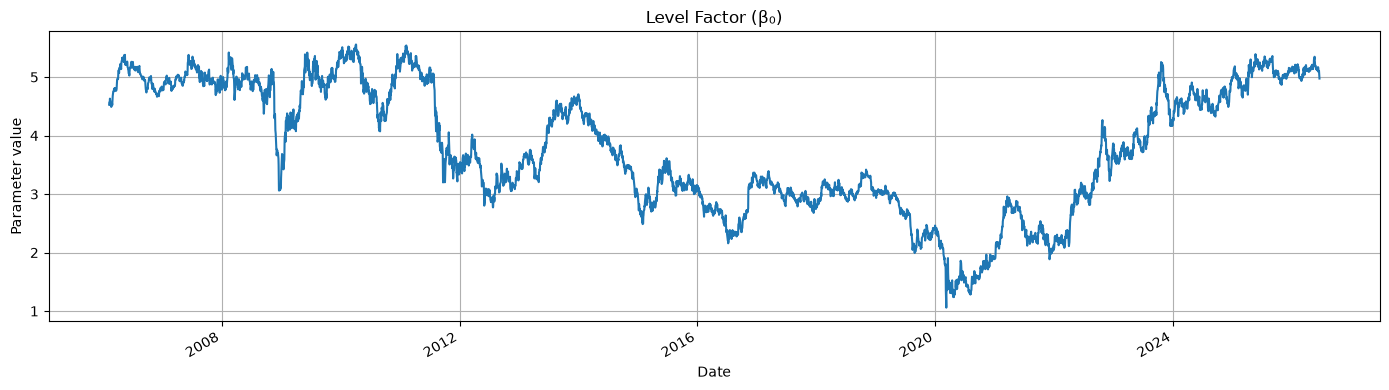

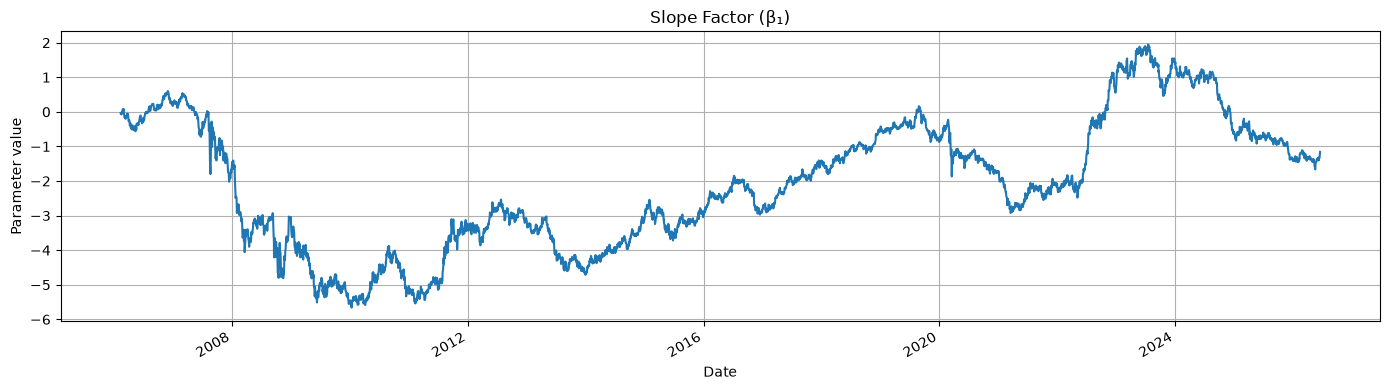

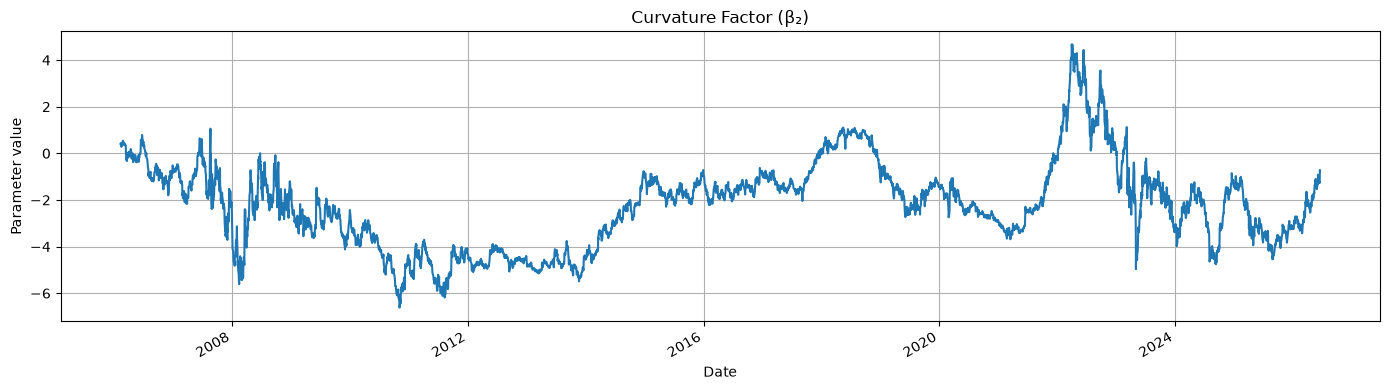

In [47]:
# ── 5.3  Plot factor time series (fixed λ) ────────────────────────────────────
for factor, title in [('beta0','Level Factor (β₀)'),
                       ('beta1','Slope Factor (β₁)'),
                       ('beta2','Curvature Factor (β₂)')]:
    ns_fixed[factor].plot(figsize=(14, 4), title=title)
    plt.ylabel('Parameter value')
    plt.tight_layout()
    plt.show()

---
## Phase 6: Lambda Optimisation via Grid Search

We tune the fixed λ by sweeping a grid and selecting the value that minimises
average RMSE across all dates.

In [48]:
# ── 6.1  RMSE helper ─────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    """Root Mean Squared Error: √[ (1/n) Σ(y - ŷ)² ]"""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

Average RMSE — Free  λ : 0.063232
Average RMSE — Fixed λ : 0.080932


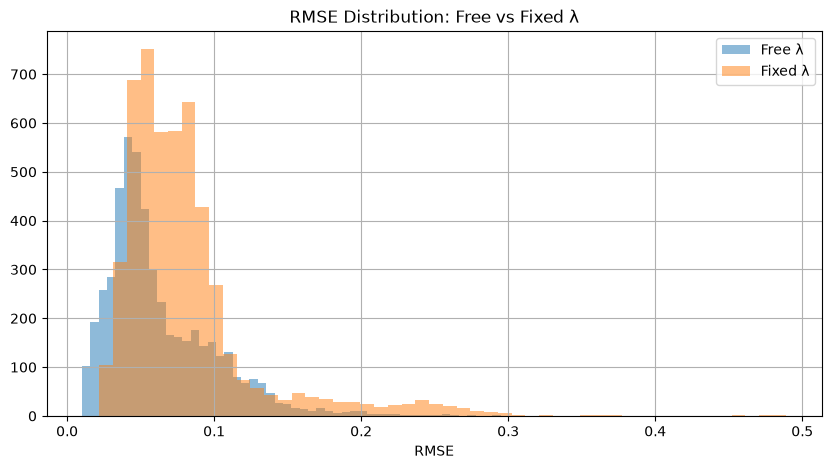

In [49]:
# ── 6.2  Free-λ vs Fixed-λ (λ=2) RMSE comparison ────────────────────────────
rmse_free_list = []
for date in df.index:
    y = df.loc[date, yield_cols].values
    b0, b1, b2, lam = ns_df.loc[date]
    y_hat = nelson_siegel(tau, b0, b1, b2, lam)
    rmse_free_list.append(rmse(y, y_hat))

rmse_fixed_list = []
for date in df.index:
    y = df.loc[date, yield_cols].values
    b0, b1, b2 = ns_fixed.loc[date]
    y_hat = nelson_siegel(tau, b0, b1, b2, lam_fixed)
    rmse_fixed_list.append(rmse(y, y_hat))

print(f'Average RMSE — Free  λ : {np.mean(rmse_free_list):.6f}')
print(f'Average RMSE — Fixed λ : {np.mean(rmse_fixed_list):.6f}')

plt.figure(figsize=(10, 5))
plt.hist(rmse_free_list,  alpha=0.5, label='Free λ',  bins=50)
plt.hist(rmse_fixed_list, alpha=0.5, label='Fixed λ', bins=50)
plt.legend()
plt.title('RMSE Distribution: Free vs Fixed λ')
plt.xlabel('RMSE')
plt.show()

λ = 0.50  →  avg RMSE = 0.268977
λ = 0.75  →  avg RMSE = 0.199063
λ = 1.00  →  avg RMSE = 0.150566
λ = 1.25  →  avg RMSE = 0.116477
λ = 1.50  →  avg RMSE = 0.094993
λ = 1.75  →  avg RMSE = 0.084485
λ = 2.00  →  avg RMSE = 0.080932
λ = 2.25  →  avg RMSE = 0.081085
λ = 2.50  →  avg RMSE = 0.083246
λ = 2.75  →  avg RMSE = 0.086432
λ = 3.00  →  avg RMSE = 0.089952
λ = 3.25  →  avg RMSE = 0.093397
λ = 3.50  →  avg RMSE = 0.096578
λ = 3.75  →  avg RMSE = 0.099438
λ = 4.00  →  avg RMSE = 0.101980
λ = 4.25  →  avg RMSE = 0.104230
λ = 4.50  →  avg RMSE = 0.106218
λ = 4.75  →  avg RMSE = 0.107978
λ = 5.00  →  avg RMSE = 0.109540

Best lambda:
lambda    2.000000
rmse      0.080932
Name: 6, dtype: float64


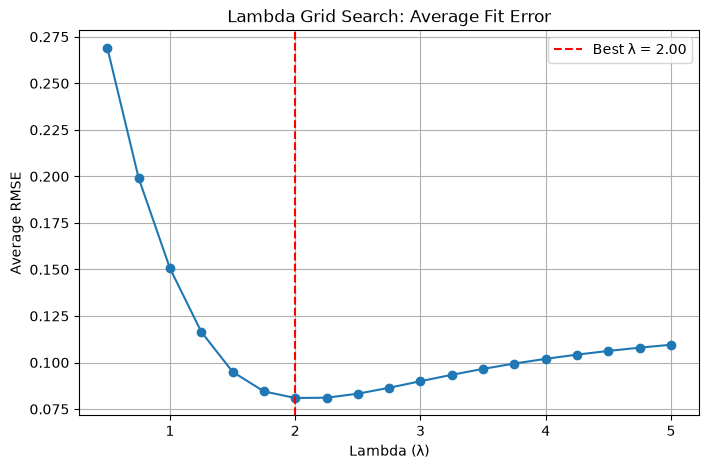

In [50]:
# ── 6.3  Grid search over lambda ──────────────────────────────────────────────
# Sweep λ from 0.5 to 5.0 in steps of 0.25 and record average RMSE.
# The optimal λ minimises the average fit error across all trading days.
lambda_grid = np.arange(0.5, 5.1, 0.25)
grid_results = []

for lam in lambda_grid:
    rmse_list = []
    for date in df.index:
        y = df.loc[date, yield_cols].values

        def obj_grid(params):
            b0, b1, b2 = params
            return np.sum((y - nelson_siegel(tau, b0, b1, b2, lam)) ** 2)

        res = minimize(obj_grid, [1, -1, 1], method='L-BFGS-B',
                       bounds=[(-10,10),(-10,10),(-10,10)])
        b0, b1, b2 = res.x
        y_hat = nelson_siegel(tau, b0, b1, b2, lam)
        rmse_list.append(rmse(y, y_hat))

    avg = np.mean(rmse_list)
    grid_results.append([lam, avg])
    print(f'λ = {lam:.2f}  →  avg RMSE = {avg:.6f}')

grid_df = pd.DataFrame(grid_results, columns=['lambda','rmse'])

best_lambda = grid_df.loc[grid_df['rmse'].idxmin()]
print('\nBest lambda:')
print(best_lambda)

plt.figure(figsize=(8, 5))
plt.plot(grid_df['lambda'], grid_df['rmse'], marker='o')
plt.axvline(best_lambda['lambda'], linestyle='--', color='red', label=f"Best λ = {best_lambda['lambda']:.2f}")
plt.xlabel('Lambda (λ)')
plt.ylabel('Average RMSE')
plt.title('Lambda Grid Search: Average Fit Error')
plt.legend()
plt.show()

---
## Phase 7: Dynamic Nelson-Siegel (DNS) via Kalman Filter

### Why Kalman Filter?
The **Dynamic Nelson-Siegel (DNS)** model (Diebold & Li, 2006) treats the three betas as a **latent state vector** evolving through time.

### State-Space Representation

**Transition equation** (how betas evolve):
$$\boldsymbol{\beta}_t = A \cdot \boldsymbol{\beta}_{t-1} + \boldsymbol{\eta}_t, \quad \boldsymbol{\eta}_t \sim \mathcal{N}(0, Q)$$

**Measurement equation** (observed yields):
$$\mathbf{y}_t = H \cdot \boldsymbol{\beta}_t + \boldsymbol{\varepsilon}_t, \quad \boldsymbol{\varepsilon}_t \sim \mathcal{N}(0, R)$$

where $H$ is the **NS factor-loading matrix** (fixed at chosen λ):

$$H = \begin{bmatrix} 1 & L_1(\tau_1,\lambda) & L_2(\tau_1,\lambda) \\ \vdots & \vdots & \vdots \\ 1 & L_1(\tau_{11},\lambda) & L_2(\tau_{11},\lambda) \end{bmatrix}
$$

### Kalman Filter Recursion
| Step | Formula |
|------|---------|
| **Predict state** | $\hat{\beta}_{t\mid t-1} = A\hat{\beta}_{t-1}$ |
| **Predict covariance** | $P_{t\mid t-1} = AP_{t-1}A^\top + Q$ |
| **Innovation** | $\nu_t = y_t - H\hat{\beta}_{t\mid t-1}$ |
| **Kalman gain** | $K_t = P_{t\mid t-1}H^\top(HP_{t\mid t-1}H^\top + R)^{-1}$ |
| **Update state** | $\hat{\beta}_t = \hat{\beta}_{t\mid t-1} + K_t \nu_t$ |
| **Update covariance** | $P_t = (I - K_t H)P_{t\mid t-1}$ |

In [51]:
# ── 7.1  Learn the transition matrix A via OLS on the fixed-λ betas ───────────
# A is estimated by regressing β_t on β_{t-1} for all three factors jointly.
# This is the VAR(1) interpretation of the DNS transition equation.

# Pairwise auto-correlations (sanity check — expect high values for β₀, β₁)
for factor in ['beta0', 'beta1', 'beta2']:
    lag_corr = ns_fixed[[factor]].copy()
    lag_corr[f'{factor}_lag'] = ns_fixed[factor].shift(1)
    r = lag_corr.corr().iloc[0, 1]
    print(f'Lag-1 autocorrelation of {factor}: {r:.4f}')

# Fit OLS transition model: β_t = A · β_{t-1}
X_reg = ns_fixed[['beta0','beta1','beta2']].shift(1).dropna()
Y_reg = ns_fixed[['beta0','beta1','beta2']].iloc[1:]

transition_model = LinearRegression(fit_intercept=False)
transition_model.fit(X_reg, Y_reg)

A = transition_model.coef_   # shape (3, 3)
print('\nTransition matrix A (each row = equation for β₀, β₁, β₂):')
print(A)

Lag-1 autocorrelation of beta0: 0.9985
Lag-1 autocorrelation of beta1: 0.9992
Lag-1 autocorrelation of beta2: 0.9953

Transition matrix A (each row = equation for β₀, β₁, β₂):
[[ 1.00035122e+00  3.97643898e-04  4.09211068e-04]
 [ 5.75995525e-04  9.97929013e-01  2.93727916e-03]
 [-3.08218315e-03  1.45792027e-03  9.93629830e-01]]


In [52]:
# ── 7.2  Build the NS factor-loading matrix H ────────────────────────────────
# H  maps the latent beta vector to observed yields:
# y_t = H · β_t    where β_t = [β₀, β₁, β₂]ᵀ
#
# Shape: (11 maturities, 3 factors)

lam = 2.0   # fixed lambda chosen from grid search

H = np.column_stack([
    np.ones(len(tau)),   # β₀ loading = 1 for all maturities
    L1(tau, lam),        # β₁ loading
    L2(tau, lam)         # β₂ loading
])

print('H matrix shape:', H.shape)  # (11, 3)
print(H)

H matrix shape: (11, 3)
[[1.         0.97945303 0.02026357]
 [1.         0.94002478 0.05752788]
 [1.         0.88479687 0.10599608]
 [1.         0.78693868 0.18040802]
 [1.         0.63212056 0.26424112]
 [1.         0.51791323 0.29478307]
 [1.         0.367166   0.285081  ]
 [1.         0.27708646 0.24688908]
 [1.         0.19865241 0.19191446]
 [1.         0.09999546 0.09995006]
 [1.         0.06666665 0.06666634]]


In [53]:
# ── 7.3  Kalman Filter — DNS estimation ──────────────────────────────────────
#
# Noise covariances (heuristic starting values):
#   Q = process noise (uncertainty in the beta dynamics)
#   R = observation noise (measurement error in yields)

beta_prev = np.zeros(3)        # initial state estimate: β₀=β₁=β₂=0
P_prev    = np.eye(3)          # initial error covariance
Q         = np.eye(3) * 0.001  # process noise covariance
R         = np.eye(11) * 0.01  # observation noise covariance

kf_betas = []

for date in df.index:
    y = df.loc[date, yield_cols].values

    # ---- PREDICTION STEP ----
    beta_pred = A @ beta_prev                      # predicted state
    P_pred    = A @ P_prev @ A.T + Q              # predicted covariance

    # ---- INNOVATION ----
    y_pred    = H @ beta_pred                      # predicted yields
    innov     = y - y_pred                         # residual (innovation)

    # ---- KALMAN GAIN ----
    S = H @ P_pred @ H.T + R                      # innovation covariance
    K = P_pred @ H.T @ np.linalg.inv(S)           # K = P·Hᵀ·S⁻¹

    # ---- UPDATE STEP ----
    beta_new = beta_pred + K @ innov               # updated state
    P_new    = (np.eye(3) - K @ H) @ P_pred       # updated covariance

    kf_betas.append([date, beta_new[0], beta_new[1], beta_new[2]])

    beta_prev = beta_new
    P_prev    = P_new

dns_df = pd.DataFrame(kf_betas, columns=['Date','beta0','beta1','beta2'])
dns_df = dns_df.set_index('Date')

print('DNS (Kalman) betas — first 5 rows:')
dns_df.head()

DNS (Kalman) betas — first 5 rows:


,beta0,beta1,beta2
Date,,,
2006-02-09,4.502976,-0.014923,0.456588
2006-02-10,4.542913,-0.030261,0.440076
2006-02-13,4.559621,-0.030742,0.395104
2006-02-14,4.588864,-0.038313,0.356385
2006-02-15,4.593161,-0.044515,0.347187


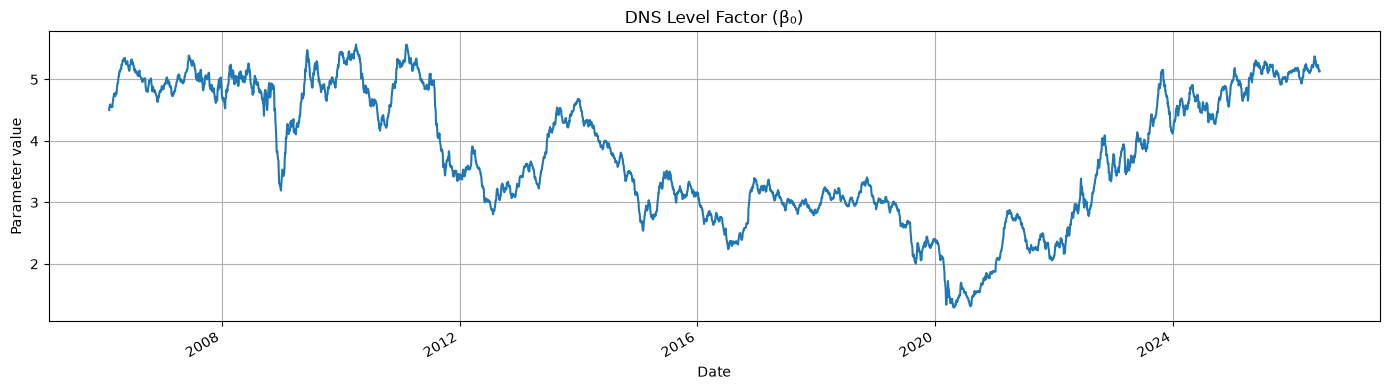

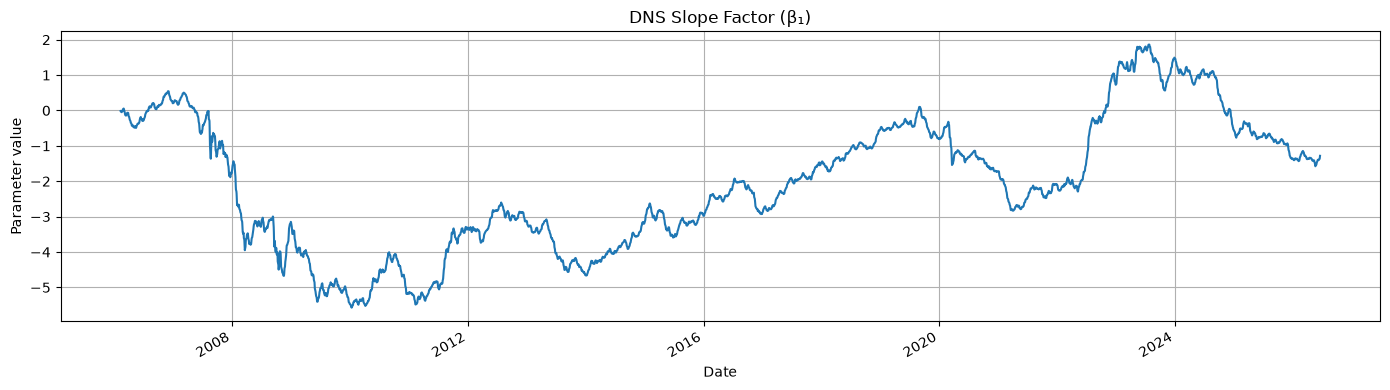

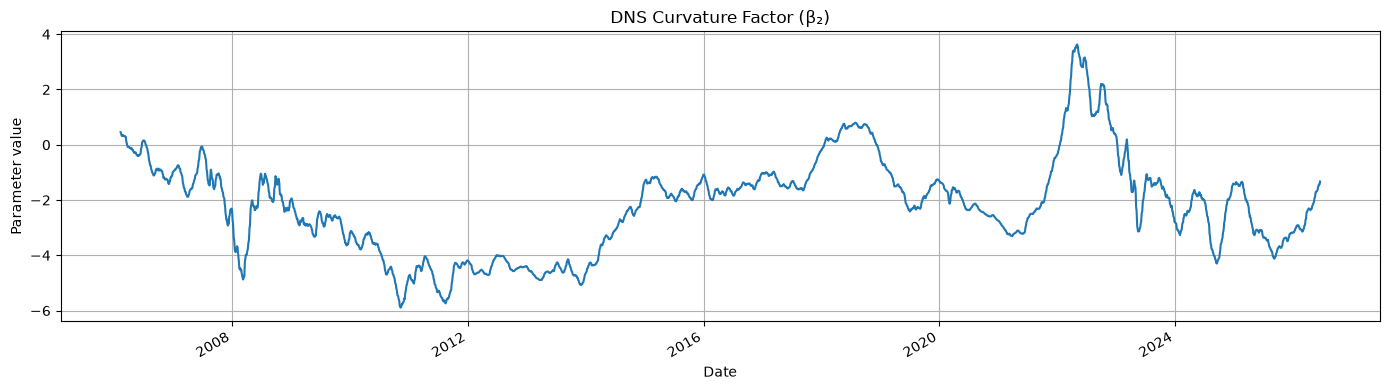

In [54]:
# ── 7.4  Plot DNS factors ─────────────────────────────────────────────────────
for factor, title in [('beta0','DNS Level Factor (β₀)'),
                       ('beta1','DNS Slope Factor (β₁)'),
                       ('beta2','DNS Curvature Factor (β₂)')]:
    dns_df[factor].plot(figsize=(14, 4), title=title)
    plt.ylabel('Parameter value')
    plt.tight_layout()
    plt.show()

---
## Phase 8: VAR Forecasting of DNS Factors

A **Vector Autoregression (VAR)** jointly models the three betas as a
multivariate time series:

$$
\boldsymbol{\beta}_t = c + \Phi_1 \boldsymbol{\beta}_{t-1} + \Phi_2 \boldsymbol{\beta}_{t-2} + \cdots + \Phi_p \boldsymbol{\beta}_{t-p} + \boldsymbol{u}_t
$$

We use a **rolling 1-step-ahead forecast** to simulate real-time prediction
and evaluate performance on the held-out test set (last 20% of dates).

In [55]:
# ── 8.1  Train/test split ────────────────────────────────────────────────────
dns_df.index = pd.DatetimeIndex(dns_df.index)
dns_df = dns_df.sort_index()

train_size = int(len(dns_df) * 0.8)
train_df   = dns_df.iloc[:train_size]
test_df    = dns_df.iloc[train_size:]

print('Train size:', train_df.shape, '|  Test size:', test_df.shape)

Train size: (4075, 3) |  Test size: (1019, 3)


In [56]:
# ── 8.2  VAR order selection (on training data) ───────────────────────────────
# Information criteria (AIC, BIC, HQIC) are used to select the optimal lag p.
var_model_sel = VAR(train_df)
var_selection = var_model_sel.select_order(10)
print(var_selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        1.444       1.448       4.237       1.445
1       -21.51      -21.49   4.553e-10      -21.50
2       -24.07      -24.04   3.512e-11      -24.06
3       -24.15     -24.10*   3.264e-11      -24.13
4       -24.15      -24.09   3.256e-11      -24.13
5       -24.16      -24.09   3.205e-11      -24.14
6       -24.17      -24.09   3.172e-11     -24.14*
7       -24.17      -24.07   3.171e-11      -24.14
8       -24.18      -24.06   3.167e-11      -24.13
9       -24.18      -24.05   3.146e-11      -24.14
10     -24.18*      -24.04  3.144e-11*      -24.13
--------------------------------------------------


In [57]:
# ── 8.3  Fit VAR(3) on training data ─────────────────────────────────────────
var_results = VAR(train_df).fit(3)
print(var_results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 07, Sep, 2026
Time:                     11:25:25
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -24.1008
Nobs:                     4072.00    HQIC:                  -24.1309
Log likelihood:           31860.3    FPE:                3.25791e-11
AIC:                     -24.1474    Det(Omega_mle):     3.23402e-11
--------------------------------------------------------------------
Results for equation beta0
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const            0.002630         0.001418            1.855           0.064
L1.beta0         1.427285         0.018602           76.727           0.000
L1.beta1        -0.137953         0.023563           -5.855           0.000
L1.b

In [58]:
# ── 8.4  Rolling 1-step-ahead VAR forecast ────────────────────────────────────
# At each test step, we re-fit VAR(3) on all data up to that point
# and forecast 1 step ahead. This avoids look-ahead bias.

var_predictions = []

for i in range(len(test_df)):
    rolling_train = dns_df.iloc[:train_size + i]
    rolling_var   = VAR(rolling_train).fit(3)
    pred = rolling_var.forecast(rolling_train.values[-3:], steps=1)
    var_predictions.append(pred[0])

var_forecast_df = pd.DataFrame(
    var_predictions,
    index=test_df.index,
    columns=['beta0','beta1','beta2']
)

print('VAR forecast shape:', var_forecast_df.shape)
var_forecast_df.head()

VAR forecast shape: (1019, 3)


,beta0,beta1,beta2
Date,,,
2022-05-20,2.906159,-2.084403,3.162122
2022-05-23,2.855266,-2.057438,3.126818
2022-05-24,2.903521,-2.075558,3.127041
2022-05-25,2.835318,-2.051961,3.044818
2022-05-26,2.816886,-2.026764,2.977476


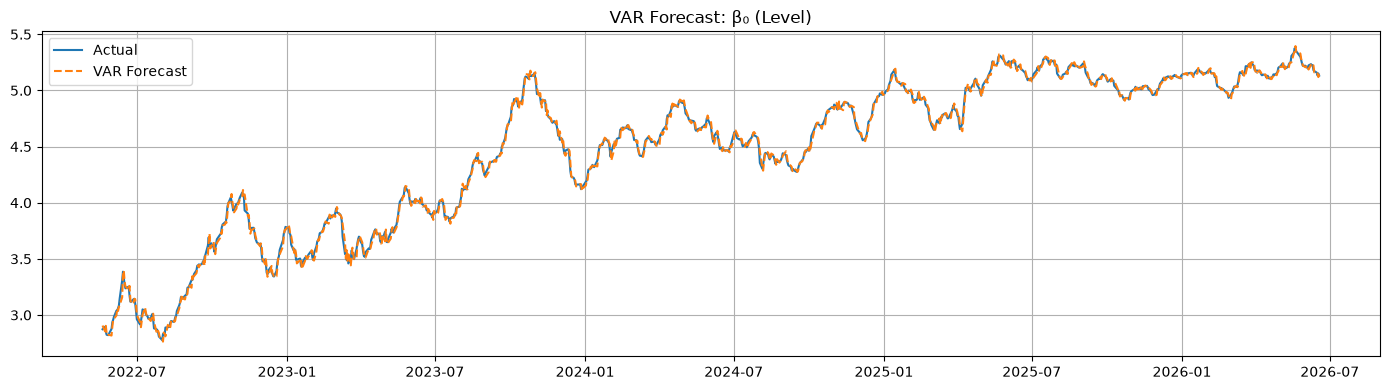

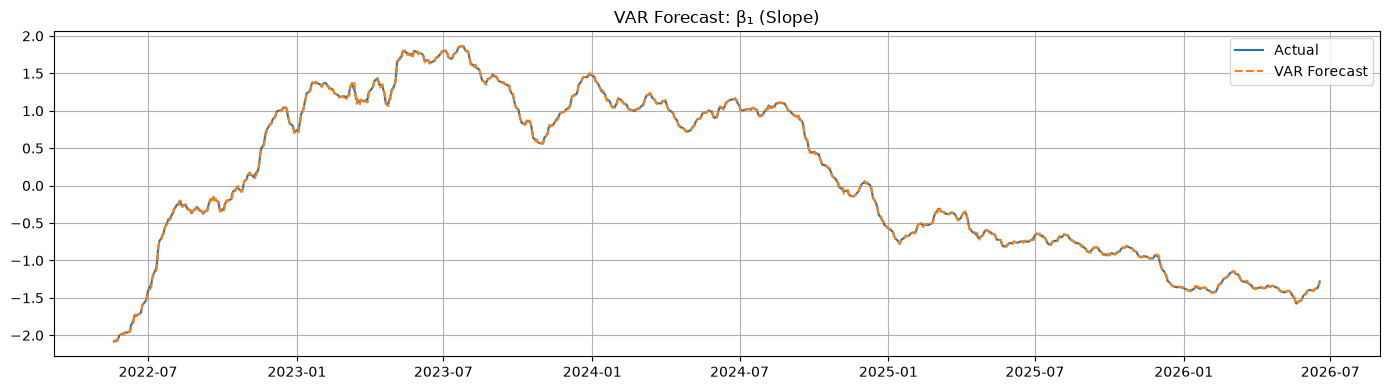

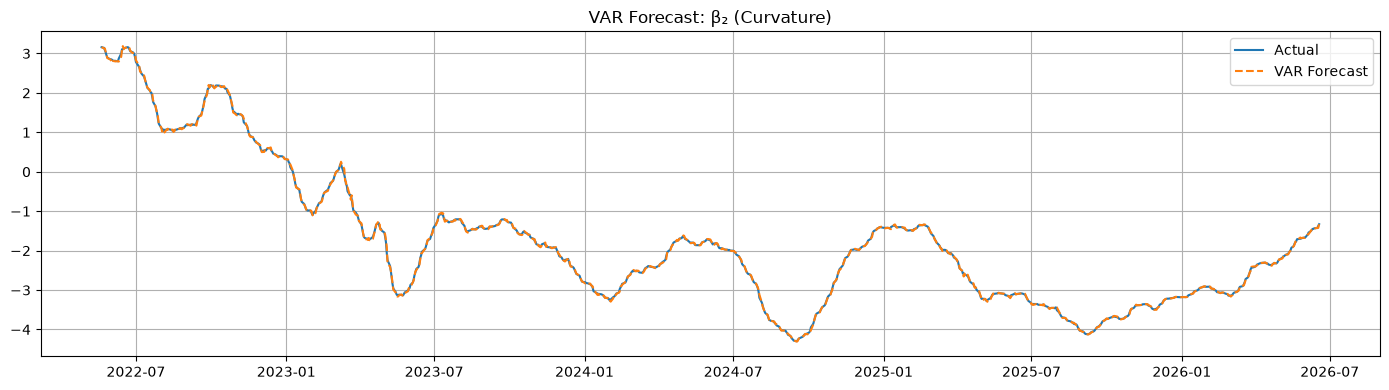

In [59]:
# ── 8.5  Plot VAR forecasts vs actual betas ───────────────────────────────────
for factor, title in [('beta0','VAR Forecast: β₀ (Level)'),
                       ('beta1','VAR Forecast: β₁ (Slope)'),
                       ('beta2','VAR Forecast: β₂ (Curvature)')]:
    plt.figure(figsize=(14, 4))
    plt.plot(test_df.index, test_df[factor], label='Actual')
    plt.plot(var_forecast_df.index, var_forecast_df[factor], label='VAR Forecast', linestyle='--')
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [60]:
# ── 8.6  VAR RMSE on betas ────────────────────────────────────────────────────
for factor in ['beta0','beta1','beta2']:
    r = np.sqrt(mean_squared_error(test_df[factor], var_forecast_df[factor]))
    print(f'VAR RMSE on {factor}: {r:.6f}')

VAR RMSE on beta0: 0.030303
VAR RMSE on beta1: 0.016504
VAR RMSE on beta2: 0.024331


---
## Phase 9: Reconstructing & Evaluating the Yield Curve from VAR Forecasts

Once we have forecasted betas, we reconstruct the full yield curve at each test date:

$$\hat{\mathbf{y}}_t = H \cdot \hat{\boldsymbol{\beta}}_t$$

In [61]:
# ── 9.1  Reconstruct yield curve from forecasted betas ────────────────────────
var_yield_forecast = []
for i in range(len(var_forecast_df)):
    beta_vec = var_forecast_df.iloc[i].values
    y_pred   = H @ beta_vec
    var_yield_forecast.append(y_pred)

var_yield_forecast_df = pd.DataFrame(
    var_yield_forecast,
    index=test_df.index,
    columns=yield_cols
)

actual_yield_test = df.loc[test_df.index, yield_cols]

print('Actual yields shape  :', actual_yield_test.shape)
print('Forecast yields shape:', var_yield_forecast_df.shape)

Actual yields shape  : (1019, 11)
Forecast yields shape: (1019, 11)


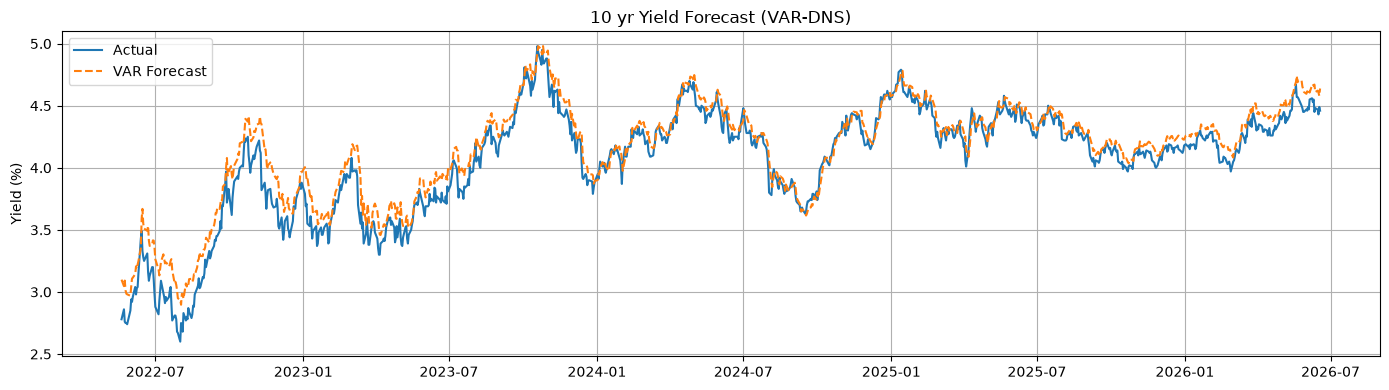

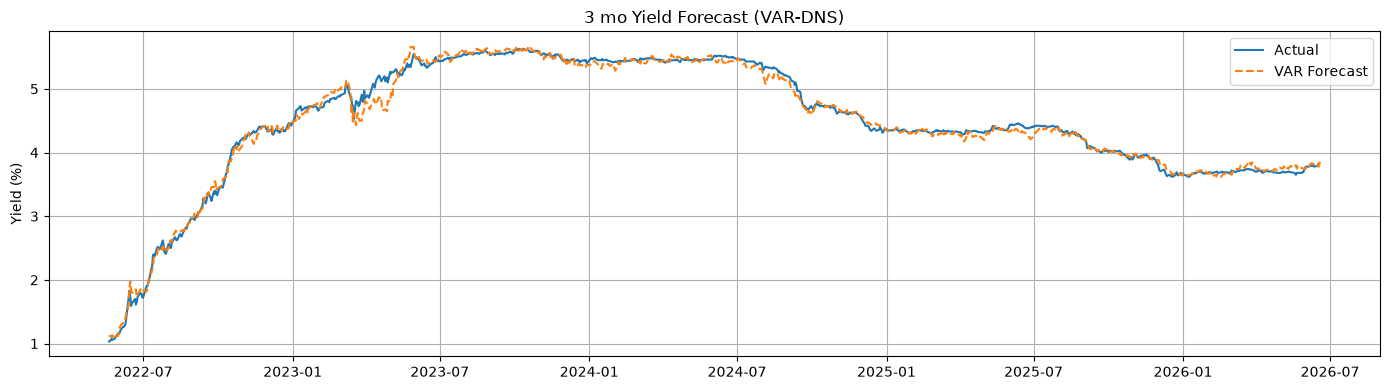

In [62]:
# ── 9.2  Plot specific maturity forecasts ────────────────────────────────────
for mat in ['10 yr', '3 mo']:
    plt.figure(figsize=(14, 4))
    plt.plot(actual_yield_test.index, actual_yield_test[mat], label='Actual')
    plt.plot(var_yield_forecast_df.index, var_yield_forecast_df[mat], label='VAR Forecast', linestyle='--')
    plt.legend()
    plt.title(f'{mat} Yield Forecast (VAR-DNS)')
    plt.ylabel('Yield (%)')
    plt.tight_layout()
    plt.show()

In [63]:
# ── 9.3  RMSE per maturity (VAR) ─────────────────────────────────────────────
var_rmse = {}
for col in actual_yield_test.columns:
    r = np.sqrt(mean_squared_error(actual_yield_test[col], var_yield_forecast_df[col]))
    var_rmse[col] = r

rmse_series = pd.Series(var_rmse)
print('VAR RMSE by maturity (%):')
print(rmse_series.sort_index())

VAR RMSE by maturity (%):
1 mo     0.248148
1 yr     0.193406
10 yr    0.132090
2 yr     0.118689
20 yr    0.164045
3 mo     0.089836
3 yr     0.099950
30 yr    0.084728
5 yr     0.124232
6 mo     0.178327
7 yr     0.117623
dtype: float64


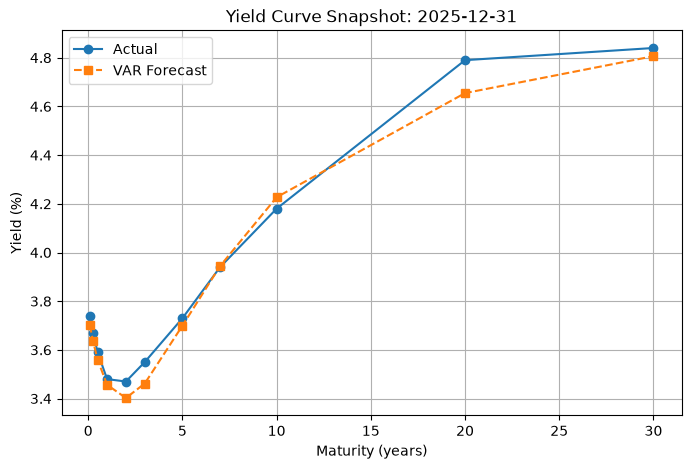

In [64]:
# ── 9.4  Cross-sectional yield curve snapshot ─────────────────────────────────
# Compare the actual vs forecast yield curve shape on a specific date.
#snapshot_date = actual_yield_test.index[-1].strftime('%Y-%m-%d')
snapshot_date = '2025-12-31'

actual_curve   = actual_yield_test.loc[snapshot_date].values
forecast_curve = var_yield_forecast_df.loc[snapshot_date].values

plt.figure(figsize=(8, 5))
plt.plot(tau, actual_curve,   marker='o', label='Actual')
plt.plot(tau, forecast_curve, marker='s', linestyle='--', label='VAR Forecast')
plt.xlabel('Maturity (years)')
plt.ylabel('Yield (%)')
plt.title(f'Yield Curve Snapshot: {snapshot_date}')
plt.legend()
plt.show()

---
## Phase 10: XGBoost Forecasting of DNS Factors

As an alternative to the linear VAR, we use **XGBoost** — a gradient boosting
tree model — to capture potential non-linear dynamics in the beta factors.

### Feature Engineering: Lagged Values
We construct lag features from each beta:

$$X_t = [\beta_0^{t-1}, \beta_0^{t-2}, \beta_0^{t-3}, \beta_0^{t-5},
         \beta_1^{t-1}, \ldots, \beta_2^{t-5}]$$

A separate XGBoost model is trained for **each of the three betas**.

In [65]:
# ── 10.1  Build lag features ─────────────────────────────────────────────────
xgb_df = dns_df.copy()

lags = [1, 2, 3, 5]
for lag in lags:
    for factor in ['beta0', 'beta1', 'beta2']:
        xgb_df[f'{factor}_lag{lag}'] = xgb_df[factor].shift(lag)

xgb_df = xgb_df.dropna()   # drop rows with NaN from lagging

feature_cols = [
    'beta0_lag1','beta0_lag2','beta0_lag3','beta0_lag5',
    'beta1_lag1','beta1_lag2','beta1_lag3','beta1_lag5',
    'beta2_lag1','beta2_lag2','beta2_lag3','beta2_lag5'
]

X = xgb_df[feature_cols]
train_size_xgb = int(len(xgb_df) * 0.8)

X_train = X.iloc[:train_size_xgb]
X_test  = X.iloc[train_size_xgb:]

print('XGBoost feature matrix shape — train:', X_train.shape, '| test:', X_test.shape)

XGBoost feature matrix shape — train: (4071, 12) | test: (1018, 12)


XGBoost RMSE — β₀: 0.038945


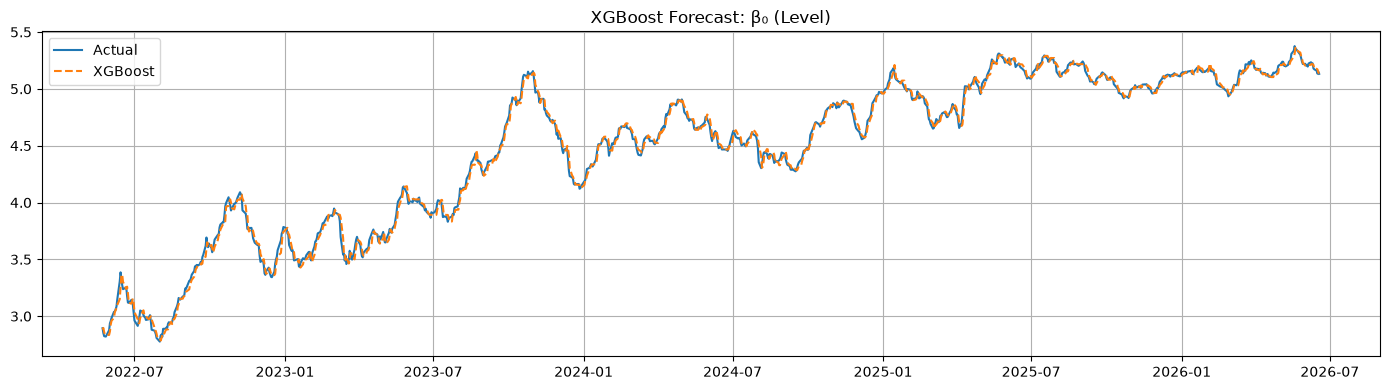

In [66]:
# ── 10.2  XGBoost for β₀ (Level) ─────────────────────────────────────────────
y_beta0 = xgb_df['beta0']
y_train_b0 = y_beta0.iloc[:train_size_xgb]
y_test_b0  = y_beta0.iloc[train_size_xgb:]

xgb_beta0 = XGBRegressor(
    n_estimators=200, max_depth=3,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, random_state=42
)
xgb_beta0.fit(X_train, y_train_b0)
b0_pred = xgb_beta0.predict(X_test)

rmse_b0_xgb = np.sqrt(mean_squared_error(y_test_b0, b0_pred))
print(f'XGBoost RMSE — β₀: {rmse_b0_xgb:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_b0.index, y_test_b0, label='Actual')
plt.plot(y_test_b0.index, b0_pred, label='XGBoost', linestyle='--')
plt.legend()
plt.title('XGBoost Forecast: β₀ (Level)')
plt.tight_layout()
plt.show()

XGBoost RMSE — β₁: 0.521212


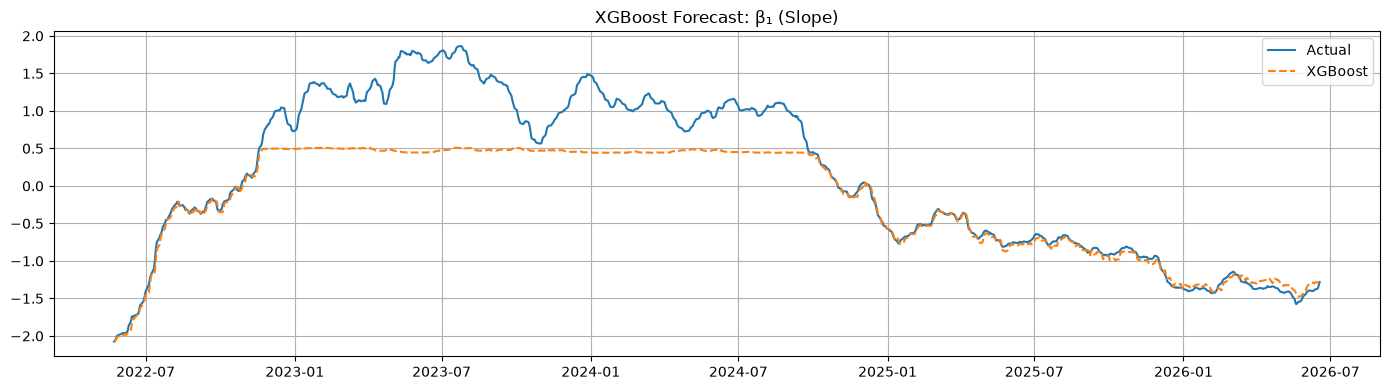

Feature importances (β₁ model):
{'beta0_lag1': np.float32(0.0004), 'beta0_lag2': np.float32(0.0003), 'beta0_lag3': np.float32(0.0), 'beta0_lag5': np.float32(1e-04), 'beta1_lag1': np.float32(0.348), 'beta1_lag2': np.float32(0.4651), 'beta1_lag3': np.float32(0.1857), 'beta1_lag5': np.float32(1e-04), 'beta2_lag1': np.float32(1e-04), 'beta2_lag2': np.float32(1e-04), 'beta2_lag3': np.float32(1e-04), 'beta2_lag5': np.float32(1e-04)}


In [67]:
# ── 10.3  XGBoost for β₁ (Slope) ─────────────────────────────────────────────
y_beta1 = xgb_df['beta1']
y_train_b1 = y_beta1.iloc[:train_size_xgb]
y_test_b1  = y_beta1.iloc[train_size_xgb:]

xgb_beta1 = XGBRegressor(
    n_estimators=500, max_depth=5,
    learning_rate=0.03, subsample=0.8,
    colsample_bytree=0.8, random_state=42
)
xgb_beta1.fit(X_train, y_train_b1)
b1_pred = xgb_beta1.predict(X_test)

rmse_b1_xgb = np.sqrt(mean_squared_error(y_test_b1, b1_pred))
print(f'XGBoost RMSE — β₁: {rmse_b1_xgb:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_b1.index, y_test_b1, label='Actual')
plt.plot(y_test_b1.index, b1_pred, label='XGBoost', linestyle='--')
plt.legend()
plt.title('XGBoost Forecast: β₁ (Slope)')
plt.tight_layout()
plt.show()

print('Feature importances (β₁ model):')
print(dict(zip(feature_cols, xgb_beta1.feature_importances_.round(4))))

XGBoost RMSE — β₂: 0.157194


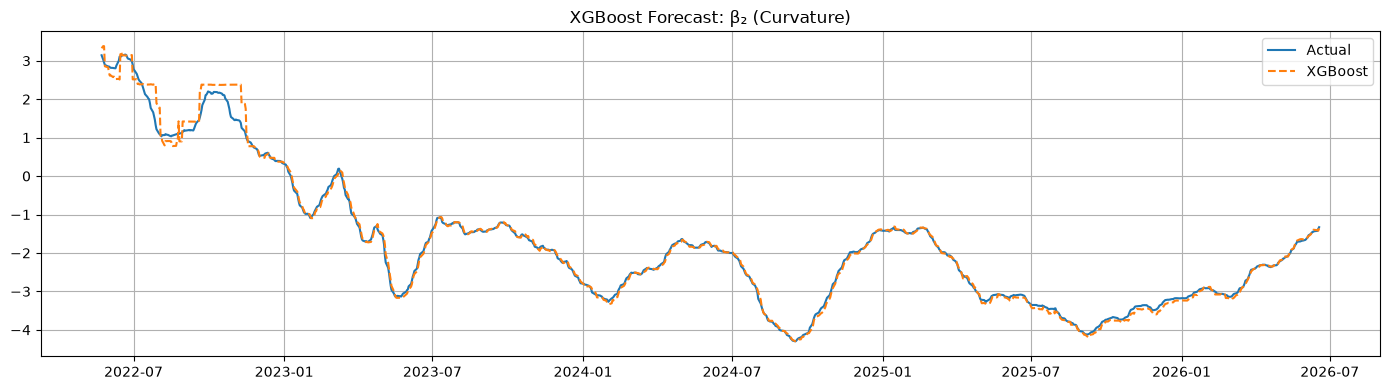

Feature importances (β₂ model):
{'beta0_lag1': np.float32(1e-04), 'beta0_lag2': np.float32(1e-04), 'beta0_lag3': np.float32(0.0006), 'beta0_lag5': np.float32(0.0005), 'beta1_lag1': np.float32(1e-04), 'beta1_lag2': np.float32(1e-04), 'beta1_lag3': np.float32(1e-04), 'beta1_lag5': np.float32(0.0002), 'beta2_lag1': np.float32(0.4593), 'beta2_lag2': np.float32(0.5218), 'beta2_lag3': np.float32(0.0118), 'beta2_lag5': np.float32(0.0054)}


In [68]:
# ── 10.4  XGBoost for β₂ (Curvature) ─────────────────────────────────────────
y_beta2 = xgb_df['beta2']
y_train_b2 = y_beta2.iloc[:train_size_xgb]
y_test_b2  = y_beta2.iloc[train_size_xgb:]

xgb_beta2 = XGBRegressor(
    n_estimators=500, max_depth=5,
    learning_rate=0.03, subsample=0.8,
    colsample_bytree=0.8, random_state=42
)
xgb_beta2.fit(X_train, y_train_b2)
b2_pred = xgb_beta2.predict(X_test)

rmse_b2_xgb = np.sqrt(mean_squared_error(y_test_b2, b2_pred))
print(f'XGBoost RMSE — β₂: {rmse_b2_xgb:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_b2.index, y_test_b2, label='Actual')
plt.plot(y_test_b2.index, b2_pred, label='XGBoost', linestyle='--')
plt.legend()
plt.title('XGBoost Forecast: β₂ (Curvature)')
plt.tight_layout()
plt.show()

print('Feature importances (β₂ model):')
print(dict(zip(feature_cols, xgb_beta2.feature_importances_.round(4))))

---
## Phase 11: Model Comparison Summary

Final comparison of VAR vs XGBoost RMSE on the DNS beta factors.

In [69]:
# ── 11.1  RMSE Summary Table ─────────────────────────────────────────────────
# Align VAR forecasts to the XGBoost test window (both use trailing 20%,
# but after lag-dropping the XGBoost window may differ slightly).
common_idx = test_df.index.intersection(y_test_b0.index)

summary = pd.DataFrame({
    'Factor' : ['β₀ (Level)', 'β₁ (Slope)', 'β₂ (Curvature)'],
    'VAR RMSE': [
        np.sqrt(mean_squared_error(test_df.loc[common_idx,'beta0'], var_forecast_df.loc[common_idx,'beta0'])),
        np.sqrt(mean_squared_error(test_df.loc[common_idx,'beta1'], var_forecast_df.loc[common_idx,'beta1'])),
        np.sqrt(mean_squared_error(test_df.loc[common_idx,'beta2'], var_forecast_df.loc[common_idx,'beta2']))
    ],
    'XGBoost RMSE': [rmse_b0_xgb, rmse_b1_xgb, rmse_b2_xgb]
})

summary = summary.set_index('Factor').round(6)
print('\n=== Model RMSE Comparison ===')
print(summary.to_string())
print('\nLower RMSE = better fit')


=== Model RMSE Comparison ===
                VAR RMSE  XGBoost RMSE
Factor                                
β₀ (Level)      0.030300      0.038945
β₁ (Slope)      0.016512      0.521212
β₂ (Curvature)  0.024342      0.157194

Lower RMSE = better fit


---
## Summary

| Phase | What we did |
|-------|-------------|
| Data Cleaning | Parsed dates, interpolated 3mo, trimmed to 2006-02-09 for full maturity coverage |
| EDA | Visualised yield history, 10Y−1Y spread, correlation heatmap, PCA (confirms 3-factor structure) |
| NS Fitting | Fitted Nelson-Siegel model per date, both free-λ and fixed-λ variants |
| λ Optimisation | Grid search over λ ∈ [0.5, 5.0]; selected optimal fixed λ = 2.0 |
| DNS (Kalman) | State-space estimation of betas using Kalman filter with OLS-estimated transition matrix A |
| VAR | Rolling 1-step VAR(3) forecast of beta dynamics; reconstructed full yield curve |
| XGBoost | Lag-feature ML forecast of each beta; separate models for β₀, β₁, β₂ |
| Comparison | RMSE across both models — VAR captures linear dynamics; XGBoost captures non-linearities |